# Effectiveness of thrombolysis and thrombectomy in early (6hr) arrivals of non-mild stroke - discharge mRS 0-1: S-Learner

A 'S-Learner' is a single model that predicts outcome based on patient characteristics and treatment received. It should include all confounders (thoughts factors that affect both outcome and propensity to treat).

## Selection criteria

* Arrival within 6 hours of known stroke onset time
* Thrombectomy, if given, given within 12 hours
* Thrombolysis, if given, given within 6 hours
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity > 5 (or labelled as LVO)

## Outcome of interest

* Discharge mRS 0-2.

## Key features of interest

* Onset to thrombolysis time
* Onset to thrombectomy time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Methodology steps

* Select patients by above criteria
* Select features by above criteria
* Split data in 5 sets, where 80% of data is used to train a model, and tets results are generated for the remaining 20% (each patient is in a single test set)
* Train 5 models
* For each model get outcome results for the tets set
* For each model, for patients treated with thrombolysis or thrombectomy, get counterfactual outcomes if they had no treatment
* Calculate the difference between actual outcome and (counterfactual) no-treatment outcomes for treated patients
* Analyse resuls for patients who 1) received thrombectomy only, 2) thrombolysis only, 3) thrombolysis or thrombectomy *

*Note - though the analysis is by different groups, the models are fitted to all groups (no treatment, thrombolysis alone, thrombectomy alone, thrombolysis + thrombectomy).

## Load modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Define mRS outcome target

In [2]:
mrs_target = 1 # Model will set y as being less than or equal to this value

CUTOFF = 270

## Define adjustment fields

In [3]:
non_categorical_features = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time']

categorical_features = [
    'stroke_team',
    'ethnicity',
]

X_fields = non_categorical_features + categorical_features

## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

# Ensure categorical columns are pandas categorical dtype for XGBoost
for col in categorical_features:
    data[col] = data[col].replace("", "Empty")
    data[col] = data[col].astype("category")

# Ensure non-categorical columns are numeric
for col in non_categorical_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Keep only teams with at least 10 onset_to_thrombectomy_time
team_counts = data.groupby("stroke_team")["onset_to_thrombectomy_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")


Initial data shape: (452863, 70)
Final data shape: (59570, 70)
Number of patients with thrombectomy: 4609
Number of patients with both thrombolysis and thrombectomy: 2876
Number of patients with only thrombectomy: 1733
Number of patients with thrombolysis: 26923
Number of patients with only thrombolysis: 24047


In [5]:
# Add treatment columns

TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_group"] = "neither"
    # Early thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "early_thrombolysis_only"
    # Late thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "late_thrombolysis_only"
    # Early thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] < CUTOFF), 
             "treatment_group"] = "early_thrombectomy_only"
    # Late thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"
    # Early thrombolysis and early thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"
    # Early thrombolysis and late thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] >= CUTOFF) & 
             (data[TIME_THROMBECTOMY] != 99999), 
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"
    # Late both thrombolysis and thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) &(data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] > CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"

    return data

data = add_treatment_columns(data)

data["patient_id"] = np.arange(len(data))

## Descriptive stats

In [6]:
DESCRIPTIVE_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time'
]

column_order = [
    'neither',
    'early_thrombolysis_only',
    'late_thrombolysis_only',
    'early_thrombectomy_only',
    'late_thrombectomy_only',
    'early_both',
    'early_thrombolysis_late_thrombectomy',
    'late_both'
]
# Create descriptive statistics table by treatment group
descriptive_stats = (
    data.groupby("treatment_group")[DESCRIPTIVE_FEATURES]
    .describe()
    .T
)

# Reorder treatment-group columns safely
descriptive_stats = descriptive_stats.reindex(columns=column_order).round(2)

# Create two columns for index
descriptive_stats = descriptive_stats.reset_index()
# Rename the columns for clarity
descriptive_stats.columns = ["feature", "statistic"] + list(descriptive_stats.columns[2:])

descriptive_stats.to_csv("./output/descriptive_stats_by_treatment_group.csv", index=False)
descriptive_stats

,feature,statistic,neither,early_thrombolysis_only,late_thrombolysis_only,early_thrombectomy_only,late_thrombectomy_only,early_both,early_thrombolysis_late_thrombectomy,late_both
0,prior_disability,count,30914.00,23074.00,973.00,1207.00,526.00,2570.00,226.00,80.00
1,prior_disability,mean,1.84,0.98,0.98,0.64,0.53,0.36,0.45,0.50
2,prior_disability,std,1.60,1.31,1.31,0.82,0.84,0.69,0.79,0.76
3,prior_disability,min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,prior_disability,25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...
75,onset_to_thrombectomy_time,min,99999.00,99999.00,99999.00,0.00,270.00,38.00,270.00,276.00
76,onset_to_thrombectomy_time,25%,99999.00,99999.00,99999.00,125.00,310.25,125.00,283.00,299.75
77,onset_to_thrombectomy_time,50%,99999.00,99999.00,99999.00,160.00,357.00,160.00,310.00,327.50
78,onset_to_thrombectomy_time,75%,99999.00,99999.00,99999.00,201.50,425.75,200.00,380.00,350.00


## Create 5 k-fold splits

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data[X_fields]
y = (data['discharge_disability'] <= mrs_target).astype(int)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []

for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]
    
    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

## Train and test models

In [8]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]
    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 0.38
    )
    # Train model
    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.8082, Balanced Accuracy = 0.6671
Split 2: AUC = 0.8130, Balanced Accuracy = 0.6773
Split 3: AUC = 0.8131, Balanced Accuracy = 0.6642
Split 4: AUC = 0.8100, Balanced Accuracy = 0.6731
Split 5: AUC = 0.8096, Balanced Accuracy = 0.6726


In [9]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred_proba = test_y_pred_probas[split]
    y_pred = test_y_preds[split]
    
    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()
    
    print(f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, Predicted positive rate = {predicted_pos_rate:.4f}")

Split 1: Actual positive rate = 0.1692, Predicted positive rate = 0.1678
Split 2: Actual positive rate = 0.1692, Predicted positive rate = 0.1751
Split 3: Actual positive rate = 0.1692, Predicted positive rate = 0.1701
Split 4: Actual positive rate = 0.1693, Predicted positive rate = 0.1705
Split 5: Actual positive rate = 0.1693, Predicted positive rate = 0.1703


## Predict counterfactual outcomes

To mimic no thrombolysis or thrombectomy, set times to 99999.

In [10]:
counter_factuals = []

for split in range(5):
    # Get model and data
    model = models[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]

    # Get index of patients who received thrombectomy or thrombolysis
    treated_indices = test_X[
        (test_X['onset_to_thrombectomy_time'] < 99999) |
        (test_X['onset_to_thrombolysis_time'] < 99999)].index

    # Get X and y for these patients
    thrombectomy_X = test_X.loc[treated_indices]
    thrombectomy_y = test_y.loc[treated_indices]

    # Get predicted probabilities for these patients
    y_probs = model.predict_proba(thrombectomy_X)[:, 1]
    
    # No thrombolysis scenario: Set onset_to_thrombolysis_time to 99999 for these patients
    no_thrombolysis_X = thrombectomy_X.copy(deep=True)
    no_thrombolysis_X['onset_to_thrombolysis_time'] = 99999
    y_probs_no_thrombolysis = model.predict_proba(no_thrombolysis_X)[:, 1]

    # No thrombectomy scenario: Set onset_to_thrombectomy_time to 99999 for these patients
    no_thrombectomy_X = thrombectomy_X.copy(deep=True)
    no_thrombectomy_X['onset_to_thrombectomy_time'] = 99999
    y_probs_no_thrombectomy = model.predict_proba(no_thrombectomy_X)[:, 1]

    # No thrombolysis and no thrombectomy scenario: Set both times to 99999
    no_both_X = thrombectomy_X.copy(deep=True)
    no_both_X['onset_to_thrombolysis_time'] = 99999
    no_both_X['onset_to_thrombectomy_time'] = 99999
    y_probs_no_both = model.predict_proba(no_both_X)[:, 1]

    # Combine X, y, and store the counterfactuals for this split
    counter_factuals_split = thrombectomy_X.copy(deep=True)
    counter_factuals_split.insert(0, 'patient_index', treated_indices)
    counter_factuals_split['actual_y'] = thrombectomy_y
    counter_factuals_split['y_prob_treated'] = y_probs
    counter_factuals_split['y_prob_no_thrombolysis'] = y_probs_no_thrombolysis
    counter_factuals_split['y_prob_no_thrombectomy'] = y_probs_no_thrombectomy
    counter_factuals_split['y_prob_no_treatment'] = y_probs_no_both
    counter_factuals_split['treatment_diff_prob'] = y_probs - y_probs_no_both
    counter_factuals.append(counter_factuals_split)

# Combine all counterfactuals into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

# Add a column of treatment group, based on times to treatment
def treatment_group(row):
    if row["onset_to_thrombolysis_time"] != 99999 and row["onset_to_thrombectomy_time"] != 99999:
        return "both"
    elif row["onset_to_thrombolysis_time"] != 99999:
        return "thrombolysis_only"
    elif row["onset_to_thrombectomy_time"] != 99999:
        return "thrombectomy_only"
    else:
        return "neither"
    
counter_factuals_df["treatment_group"] = counter_factuals_df.apply(treatment_group, axis=1)

In [11]:
# Define columns for probabilities and compute log-odds
prob_cols = [
    'y_prob_treated',
    'y_prob_no_thrombolysis',
    'y_prob_no_thrombectomy',
    'y_prob_no_treatment',
]

# Convert predicted probabilities to clipped log-odds columns
for col in prob_cols:
    clipped = counter_factuals_df[col].clip(1e-9, 1 - 1e-9)
    log_odds_col = col.replace('y_prob_', 'log_odds_')
    counter_factuals_df[log_odds_col] = np.log(clipped / (1 - clipped))

diff_pairs = {
    'log_odds_diff_treated_no_thrombolysis': 'log_odds_no_thrombolysis',
    'log_odds_diff_treated_no_thrombectomy': 'log_odds_no_thrombectomy',
    'log_odds_diff_treated_no_treatment': 'log_odds_no_treatment',
}

for diff_col, ref_col in diff_pairs.items():
    counter_factuals_df[diff_col] = (
        counter_factuals_df['log_odds_treated'] - counter_factuals_df[ref_col]
    )

## Descriptive statistics of all patients in model

In [12]:
counter_factuals_df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_index,28656.0,232504.865543,132271.633784,10.000000,118128.000000,237397.500000,347432.500000,452855.000000
prior_disability,28656.0,0.900614,1.255120,0.000000,0.000000,0.000000,2.000000,5.000000
stroke_severity,28639.0,13.250253,6.283064,0.000000,8.000000,12.000000,18.000000,42.000000
age,28656.0,73.828867,13.288928,37.500000,67.500000,77.500000,82.500000,92.500000
congestive_heart_failure,28656.0,0.051612,0.221247,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,28656.0,0.542923,0.498163,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,28656.0,0.207566,0.405571,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,28656.0,0.059743,0.237015,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,28656.0,0.235204,0.424134,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,28656.0,6204.861146,23796.987305,14.000000,127.000000,165.000000,218.000000,99999.000000


Descriptive statistics for treatment group: thrombectomy_only

In [13]:
group = 'thrombectomy_only'
group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == group]
print(f"\nDescriptive stats for treatment group: {group}")
group_df.describe().T


Descriptive stats for treatment group: thrombectomy_only


,count,mean,std,min,25%,50%,75%,max
patient_index,1733.0,305759.438546,92575.455962,105650.000000,234130.000000,310262.000000,385344.000000,452563.000000
prior_disability,1733.0,0.609348,0.824190,0.000000,0.000000,0.000000,1.000000,5.000000
stroke_severity,1732.0,16.099885,6.137916,0.000000,11.000000,16.000000,21.000000,40.000000
age,1733.0,73.336699,12.898090,37.500000,67.500000,77.500000,82.500000,92.500000
congestive_heart_failure,1733.0,0.083670,0.276972,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,1733.0,0.545874,0.498035,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,1733.0,0.186959,0.389991,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,1733.0,0.459896,0.498533,0.000000,0.000000,0.000000,1.000000,1.000000
any_afib_diagnosis,1733.0,0.518177,0.499814,0.000000,0.000000,1.000000,1.000000,1.000000
onset_to_thrombolysis_time,1733.0,99999.000000,0.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000


Descriptive statistics for treatment group: thrombolysis only

In [14]:
group = 'thrombolysis_only'
group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == group]
print(f"\nDescriptive stats for treatment group: {group}")
group_df.describe().T


Descriptive stats for treatment group: thrombolysis_only


,count,mean,std,min,25%,50%,75%,max
patient_index,24047.0,219479.657961,134262.997159,10.000000,99143.000000,218027.000000,336487.000000,452855.000000
prior_disability,24047.0,0.984821,1.312634,0.000000,0.000000,0.000000,2.000000,5.000000
stroke_severity,24031.0,12.702967,6.174747,0.000000,7.000000,11.000000,17.000000,42.000000
age,24047.0,74.224124,13.288302,37.500000,67.500000,77.500000,82.500000,92.500000
congestive_heart_failure,24047.0,0.050526,0.219032,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,24047.0,0.547844,0.497716,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,24047.0,0.214912,0.410770,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,24047.0,0.034433,0.182341,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,24047.0,0.213831,0.410018,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,24047.0,169.253545,56.218943,14.000000,126.000000,162.000000,208.000000,359.000000


Descriptive statistics for treatment group: thrombolysis + thrombectomy

In [15]:
group = 'both'
group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == group]
print(f"\nDescriptive stats for treatment group: {group}")
group_df.describe().T


Descriptive stats for treatment group: both


,count,mean,std,min,25%,50%,75%,max
patient_index,2876.0,297270.857093,97959.112405,106695.000000,220318.750000,305503.500000,383570.500000,452623.000000
prior_disability,2876.0,0.372045,0.700785,0.000000,0.000000,0.000000,1.000000,5.000000
stroke_severity,2876.0,16.107093,6.025656,0.000000,11.000000,16.000000,20.000000,37.000000
age,2876.0,70.820584,13.134600,37.500000,62.500000,72.500000,82.500000,92.500000
congestive_heart_failure,2876.0,0.041377,0.199195,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,2876.0,0.500000,0.500087,0.000000,0.000000,0.500000,1.000000,1.000000
diabetes,2876.0,0.158554,0.365323,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,2876.0,0.030250,0.171305,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,2876.0,0.243394,0.429205,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,2876.0,152.362309,55.406465,22.000000,112.000000,142.000000,185.000000,358.000000


Get mean, standard deviation, and n for each treatment group

In [16]:
# Get mean, standard deviation, and n for each feature in each treatment group, and store in a DataFrame
treatments_groups = ['both', 'thrombolysis_only', 'thrombectomy_only']
treatment_effects = ['y_prob_treated','y_prob_no_treatment', 'treatment_diff_prob', 'log_odds_no_treatment']
# Get mean, standard deviation, and n for each treatment effect in treatment group, and store in a DataFrame
summary_stats = []
for treatment in treatments_groups:
    for effect in treatment_effects:
        group_df = counter_factuals_df[counter_factuals_df['treatment_group'] == treatment]
        mean = group_df[effect].mean()
        std = group_df[effect].std()
        n = group_df[effect].count()
        summary_stats.append({
            'treatment_group': treatment,
            'treatment_effect': effect,
            'mean': mean,
            'std': std,
            'n': n
        })
summary_stats_df = pd.DataFrame(summary_stats).round(3)
summary_stats_df

,treatment_group,treatment_effect,mean,std,n
0,both,y_prob_treated,0.270,0.245,2876
1,both,y_prob_no_treatment,0.190,0.191,2876
2,both,treatment_diff_prob,0.080,0.185,2876
3,both,log_odds_no_treatment,-2.144,1.741,2876
4,thrombolysis_only,y_prob_treated,0.308,0.268,24047
5,thrombolysis_only,y_prob_no_treatment,0.220,0.222,24047
6,thrombolysis_only,treatment_diff_prob,0.088,0.125,24047
7,thrombolysis_only,log_odds_no_treatment,-2.230,2.238,24047
8,thrombectomy_only,y_prob_treated,0.182,0.213,1733
9,thrombectomy_only,y_prob_no_treatment,0.171,0.189,1733


Add 60 minute bins of thrombolysis and thrombectomy time.

In [17]:
# 60-minute bins up to 720, plus sentinel 99999
bin_edges = list(range(0, 361, 60)) + [99999]

# Labels like 0-120, 120-240, ..., 600-720, No treatment
bin_labels = [
    f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges) - 2)] + ["No thrombolysis"]
counter_factuals_df['thrombolysis_bin'] = pd.cut(
    counter_factuals_df['onset_to_thrombolysis_time'],
    bins=bin_edges,
    labels=bin_labels,
    right=True,
    include_lowest=True
)

bin_edges = list(range(0, 721, 60)) + [99999]
bin_labels = [
    f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges) - 2)] + ["No thrombectomy"]
counter_factuals_df['thrombectomy_bin'] = pd.cut(
    counter_factuals_df['onset_to_thrombectomy_time'],
    bins=bin_edges,
    labels=bin_labels,
    right=True,
    include_lowest=True
)

## Plot heatmap of benefit vs thrombolysis and thrombectomy time

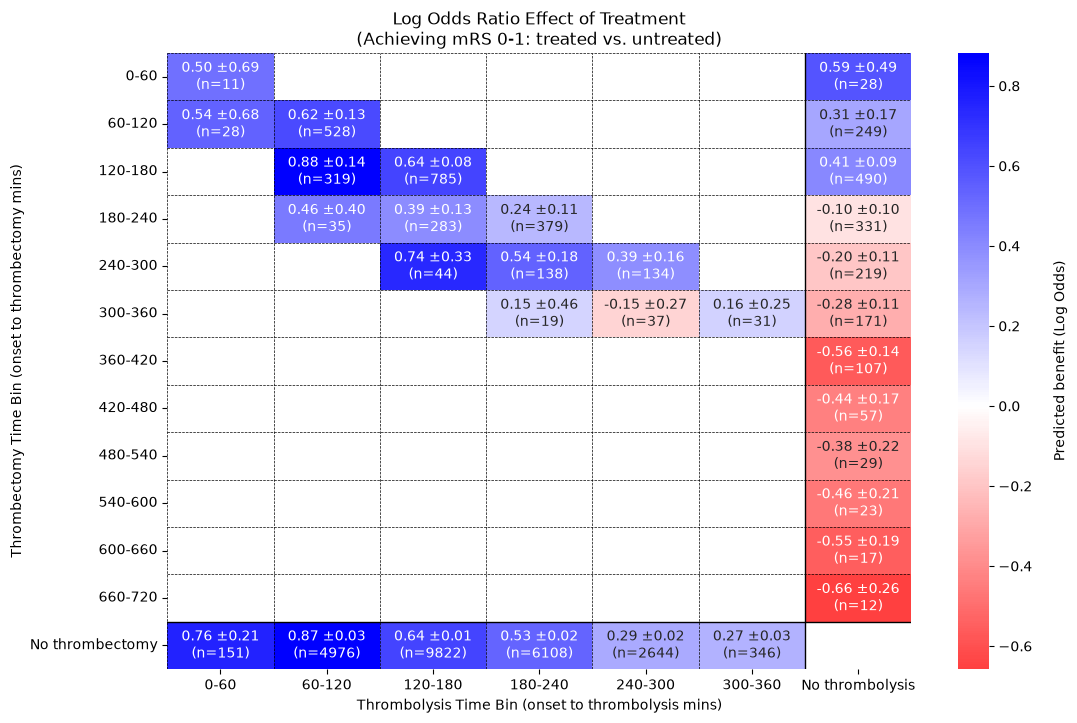

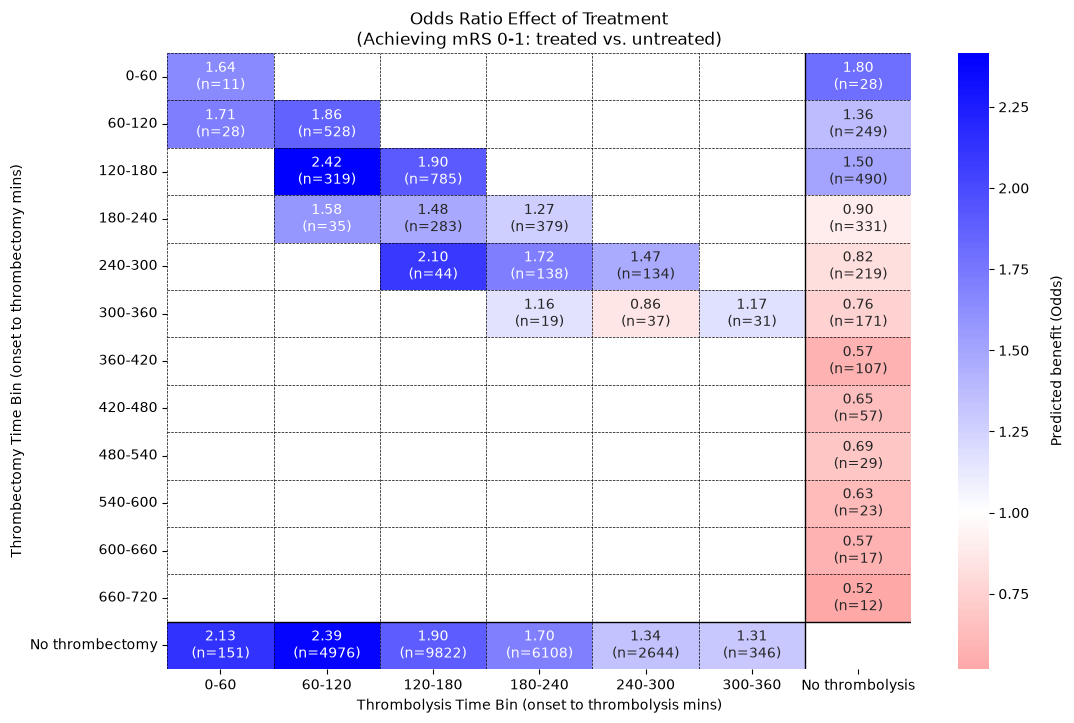

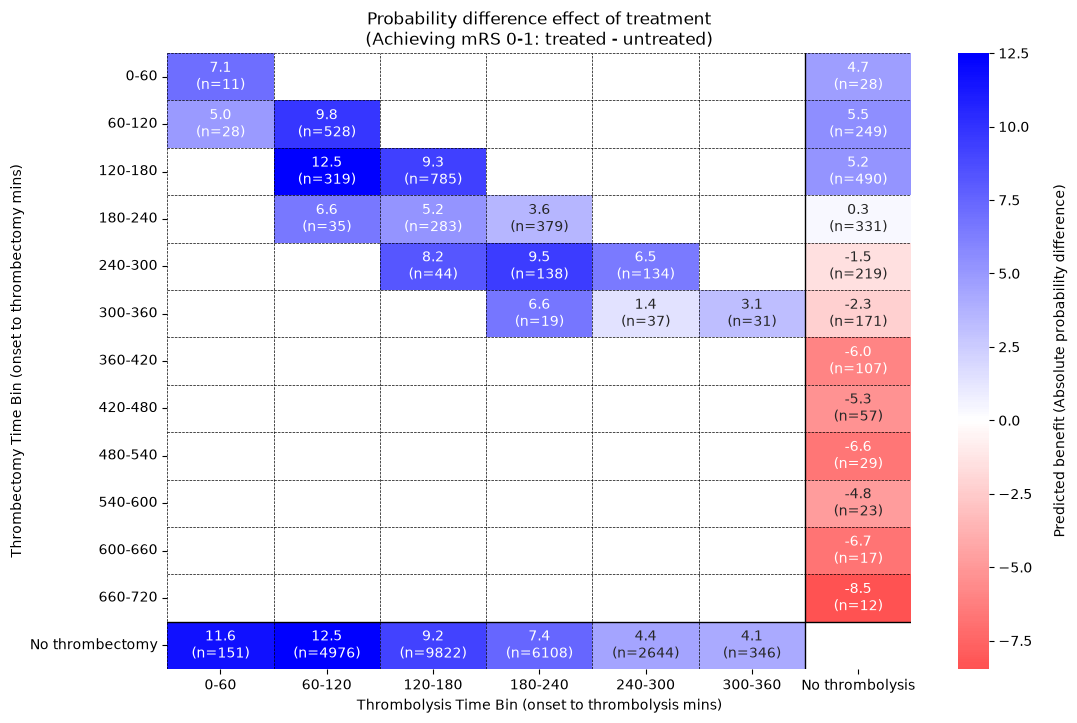

In [18]:
# Preoduce heatmap of difference to no treatment for thrombectomy and thrombolysis, with bins on x and y axes
heatmap_data = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='log_odds_diff_treated_no_treatment',
    aggfunc='mean'
)

# Remove any cells where the count is less than 5 to avoid unreliable estimates
heatmap_counts = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='patient_index',
    aggfunc='count'
)

# Filter heatmap_data to only include cells with counts >= 10
heatmap_data = heatmap_data.where(heatmap_counts >= 10)

# Compute standard deviation per cell, needed for the 95% CI
heatmap_std = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='log_odds_diff_treated_no_treatment',
    aggfunc='std'
)

# Filter heatmap_data to only include cells with counts >= 10
heatmap_data = heatmap_data.where(heatmap_counts >= 10)
heatmap_std = heatmap_std.where(heatmap_counts >= 10)

# Create annotation labels without changing heatmap_data numeric dtype
heatmap_annot = heatmap_data.apply(
    lambda col: col.map(lambda v: f"{float(v):.2f}" if pd.notna(v) else "")
)

# Add 95% confidence intervals to the annotation labels
z = 1.96
heatmap_ci = z * heatmap_std / np.sqrt(heatmap_counts)
heatmap_annot = heatmap_annot + heatmap_ci.apply(
    lambda col: col.map(lambda v: f" \u00b1{float(v):.2f}" if pd.notna(v) else "")
)

# Add (n=count) to the annotation labels
heatmap_annot = heatmap_annot + heatmap_counts.apply(
    lambda col: col.map(lambda v: f"\n(n={int(v)})" if pd.notna(v) and v >=10 else ""))


# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='bwr_r', center=0, annot=heatmap_annot, fmt='')
plt.title(f'Log Odds Ratio Effect of Treatment\n(Achieving mRS 0-{mrs_target}: treated vs. untreated)')

# Add lines between all bins
for i in range(len(bin_labels)):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.5)
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.5)

# Count the number of bins for thrombolysis and thrombectomy,
# and draw a solid line at the last bin for each axis.
thrombolysis_bin_count = len(counter_factuals_df['thrombolysis_bin'].cat.categories)
thrombectomy_bin_count = len(counter_factuals_df['thrombectomy_bin'].cat.categories)
plt.axvline(x=thrombolysis_bin_count - 1, color='black', linestyle='-', linewidth=1)
plt.axhline(y=thrombectomy_bin_count - 1, color='black', linestyle='-', linewidth=1)

# Add a label to the colorbar
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Predicted benefit (Log Odds)', rotation=90, labelpad=15)

plt.xlabel('Thrombolysis Time Bin (onset to thrombolysis mins)')
plt.ylabel('Thrombectomy Time Bin (onset to thrombectomy mins)')
plt.savefig(f'./output/thrombolysis_thrombectomy_heatmap_mrs_{mrs_target}.png',
            dpi=300, bbox_inches='tight')
plt.show()

################################################################################
# Repeat the heatmap but with lod odds convert to odds (exp log odds)
################################################################################

heatmap_data_odds = np.exp(heatmap_data)
heatmap_annot_odds = heatmap_data_odds.apply(
    lambda col: col.map(lambda v: f"{float(v):.2f}" if pd.notna(v) else "")
)
# Add (n=count) to the annotation labels
heatmap_annot_odds = heatmap_annot_odds + heatmap_counts.apply(
    lambda col: col.map(lambda v: f"\n(n={int(v)})" if pd.notna(v) and v >=10 else "")
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_odds, cmap='bwr_r', center=1, annot=heatmap_annot_odds, fmt='')
plt.title(f'Odds Ratio Effect of Treatment\n(Achieving mRS 0-{mrs_target}: treated vs. untreated)')

# Add lines between all bins
for i in range(len(bin_labels)):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.5)
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.5)

# Count the number of bins for thrombolysis and thrombectomy,
# and draw a solid line at the last bin for each axis.
plt.axvline(x=thrombolysis_bin_count - 1, color='black', linestyle='-', linewidth=1)
plt.axhline(y=thrombectomy_bin_count - 1, color='black', linestyle='-', linewidth=1)

# Add a label to the colorbar
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Predicted benefit (Odds)', rotation=90, labelpad=15)

plt.xlabel('Thrombolysis Time Bin (onset to thrombolysis mins)')
plt.ylabel('Thrombectomy Time Bin (onset to thrombectomy mins)')
plt.savefig(f'./output/thrombolysis_thrombectomy_heatmap_odds_mrs_{mrs_target}.png',
            dpi=300, bbox_inches='tight')
plt.show()


################################################################################
# Repeat for treatment_difference (y_probs - y_probs_no_both) instead of log 
# odds difference 
################################################################################

heatmap_data = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='treatment_diff_prob',
    aggfunc='mean'
)

# Remove any cells where the count is less than 5 to avoid unreliable estimates
heatmap_counts = counter_factuals_df.pivot_table(
    index='thrombectomy_bin',
    columns='thrombolysis_bin',
    values='patient_index',
    aggfunc='count'
)

# Filter heatmap_data to only include cells with counts >= 10
heatmap_data_diff = heatmap_data.where(heatmap_counts >= 10)

# Convert to percentage
heatmap_data_diff = heatmap_data_diff * 100

# Create annotation labels without changing heatmap_data numeric dtype
heatmap_annot = heatmap_data_diff.apply(
    lambda col: col.map(lambda v: f"{float(v):.1f}" if pd.notna(v) else "")
)
# Add (n=count) to the annotation labels
heatmap_annot = heatmap_annot + heatmap_counts.apply(
    lambda col: col.map(lambda v: f"\n(n={int(v)})" if pd.notna(v) and v >=10 else ""))


# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_diff, cmap='bwr_r', center=0, annot=heatmap_annot, fmt='')
plt.title(f'Probability difference effect of treatment\n(Achieving mRS 0-{mrs_target}: treated - untreated)')
# Add lines between all bins
for i in range(len(bin_labels)):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.5)
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.5)

# Count the number of bins for thrombolysis and thrombectomy,
# and draw a solid line at the last bin for each axis.
plt.axvline(x=thrombolysis_bin_count - 1, color='black', linestyle='-', linewidth=1)
plt.axhline(y=thrombectomy_bin_count - 1, color='black', linestyle='-', linewidth=1)

# Add a label to the colorbar
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Predicted benefit (Absolute probability difference)', rotation=90, labelpad=15)

plt.xlabel('Thrombolysis Time Bin (onset to thrombolysis mins)')
plt.ylabel('Thrombectomy Time Bin (onset to thrombectomy mins)')
plt.savefig(f'./output/thrombolysis_thrombectomy_heatmap_diff_prob_mrs_{mrs_target}.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Regression on time to thrombolysis and time to thrombectomy, when both given

In [19]:
# Get data for patients who thrombectomy and thrombolysis
both_treatments = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombectomy_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombolysis_time"] < 99999)
].copy()

# Fit multiple regression model for predicted benefit vs thrombolysis time
reg_X = both_treatments[["onset_to_thrombolysis_time", "onset_to_thrombectomy_time"]]
reg_y = both_treatments["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.019
Model:                                            OLS   Adj. R-squared:                  0.018
Method:                                 Least Squares   F-statistic:                     27.41
Date:                                Sun, 09 Aug 2026   Prob (F-statistic):           1.61e-12
Time:                                        12:28:06   Log-Likelihood:                -4646.2
No. Observations:                                2876   AIC:                             9298.
Df Residuals:                                    2873   BIC:                             9316.
Df Model:                                           2                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

Plot contour map

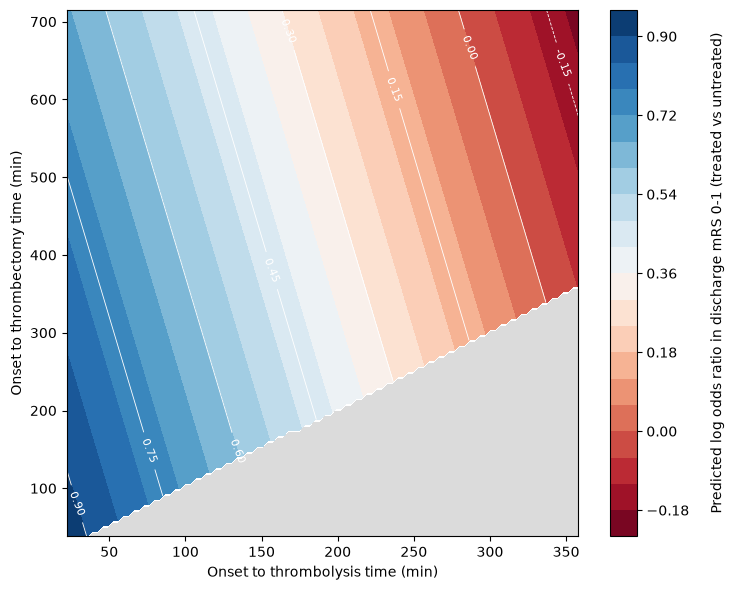

In [20]:
x1_grid = np.linspace(reg_X["onset_to_thrombolysis_time"].min(),
                       reg_X["onset_to_thrombolysis_time"].max(), 100)
x2_grid = np.linspace(reg_X["onset_to_thrombectomy_time"].min(),
                       reg_X["onset_to_thrombectomy_time"].max(), 100)

xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

const = model.params["const"]
c1 = model.params["onset_to_thrombolysis_time"]
c2 = model.params["onset_to_thrombectomy_time"]

zz = const + c1 * xx1 + c2 * xx2

# Mask points where thrombolysis time exceeds thrombectomy time
invalid_mask = xx1 > xx2
zz_masked = np.ma.masked_where(invalid_mask, zz)

fig, ax = plt.subplots(figsize=(7.5, 6))
cs_fill = ax.contourf(xx1, xx2, zz_masked, levels=20, cmap="RdBu")
cs_lines = ax.contour(xx1, xx2, zz_masked, levels=10, colors="white", linewidths=0.6)
ax.clabel(cs_lines, inline=True, fontsize=8, fmt="%.2f")

# Optionally shade the excluded region for clarity
ax.contourf(xx1, xx2, invalid_mask, levels=[0.5, 1.5], colors="lightgrey", alpha=0.8)

cbar = fig.colorbar(cs_fill, ax=ax)
cbar.set_label(
    f"Predicted log odds ratio in discharge mRS 0-{mrs_target} (treated vs untreated)",
    labelpad=15)

#ax.set_title("Predicted outcome across both time predictors")
ax.set_xlabel("Onset to thrombolysis time (min)")
ax.set_ylabel("Onset to thrombectomy time (min)")
fig.tight_layout()
fig.savefig(f"./output/contour_plot_mRS_{mrs_target}.png", dpi=300)
plt.show()

Marginal effect plots

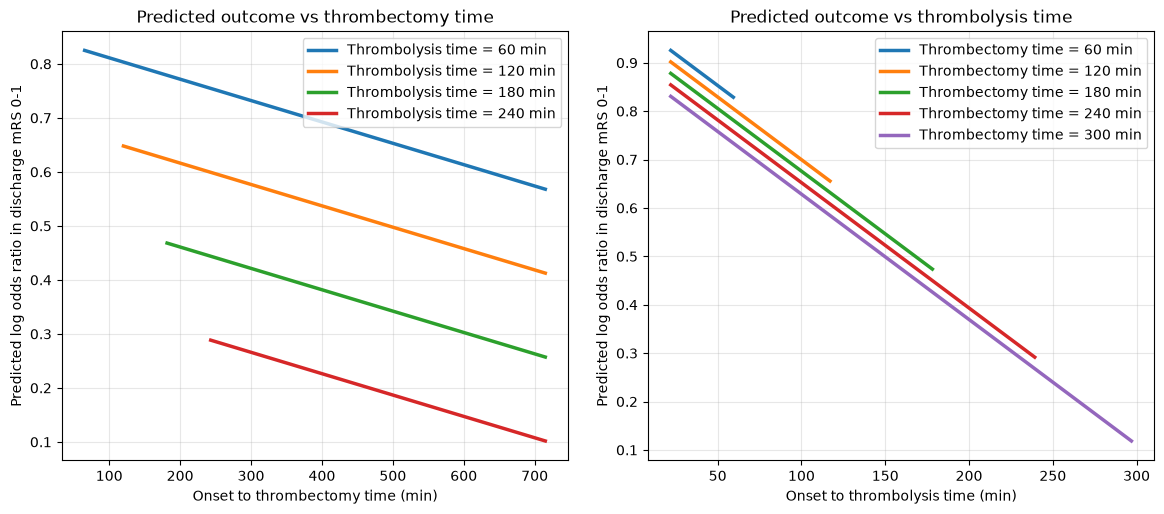

In [21]:
const = model.params["const"]
c1 = model.params["onset_to_thrombolysis_time"]
c2 = model.params["onset_to_thrombectomy_time"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Left panel: thrombectomy time on x-axis, lines fixed at thrombolysis times
thrombolysis_vals = [60, 120, 180, 240]
colors_left = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

x2_range = np.linspace(reg_X["onset_to_thrombectomy_time"].min(),
                        reg_X["onset_to_thrombectomy_time"].max(), 100)

ax = axes[0]
for x1_val, color in zip(thrombolysis_vals, colors_left):
    valid_mask = x2_range >= x1_val
    x2_valid = x2_range[valid_mask]
    y_pred = const + c1 * x1_val + c2 * x2_valid
    ax.plot(x2_valid, y_pred, color=color, linewidth=2.5,
            label=f"Thrombolysis time = {x1_val} min")

ax.set_title("Predicted outcome vs thrombectomy time")
ax.set_xlabel("Onset to thrombectomy time (min)")
ax.set_ylabel(f"Predicted log odds ratio in discharge mRS 0-{mrs_target}")
ax.legend()
ax.grid(alpha=0.3)

# Right panel: thrombolysis time on x-axis, lines fixed at thrombectomy times
thrombectomy_vals = [60, 120, 180, 240, 300]
colors_right = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

x1_range = np.linspace(reg_X["onset_to_thrombolysis_time"].min(),
                        reg_X["onset_to_thrombolysis_time"].max(), 100)

ax = axes[1]
for x2_val, color in zip(thrombectomy_vals, colors_right):
    valid_mask = x1_range <= x2_val
    x1_valid = x1_range[valid_mask]
    y_pred = const + c1 * x1_valid + c2 * x2_val
    ax.plot(x1_valid, y_pred, color=color, linewidth=2.5,
            label=f"Thrombectomy time = {x2_val} min")

ax.set_title("Predicted outcome vs thrombolysis time")
ax.set_xlabel("Onset to thrombolysis time (min)")
ax.set_ylabel(f"Predicted log odds ratio in discharge mRS 0-{mrs_target}")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout(pad=2.0)
fig.savefig(f"./output/marginal_effect_plot_mRS_{mrs_target}.png", dpi=300)
plt.show()


## Analysis of thrombectomy alone

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.086
Model:                                            OLS   Adj. R-squared:                  0.085
Method:                                 Least Squares   F-statistic:                     162.5
Date:                                Sun, 09 Aug 2026   Prob (F-statistic):           1.24e-35
Time:                                        12:28:07   Log-Likelihood:                -2458.6
No. Observations:                                1733   AIC:                             4921.
Df Residuals:                                    1731   BIC:                             4932.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

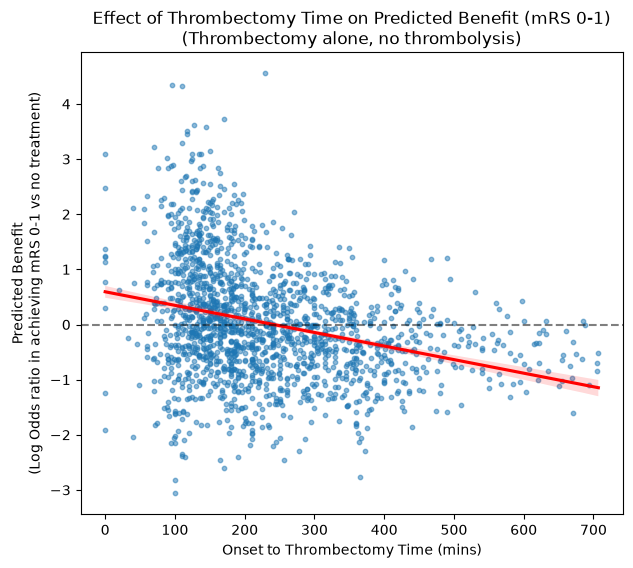

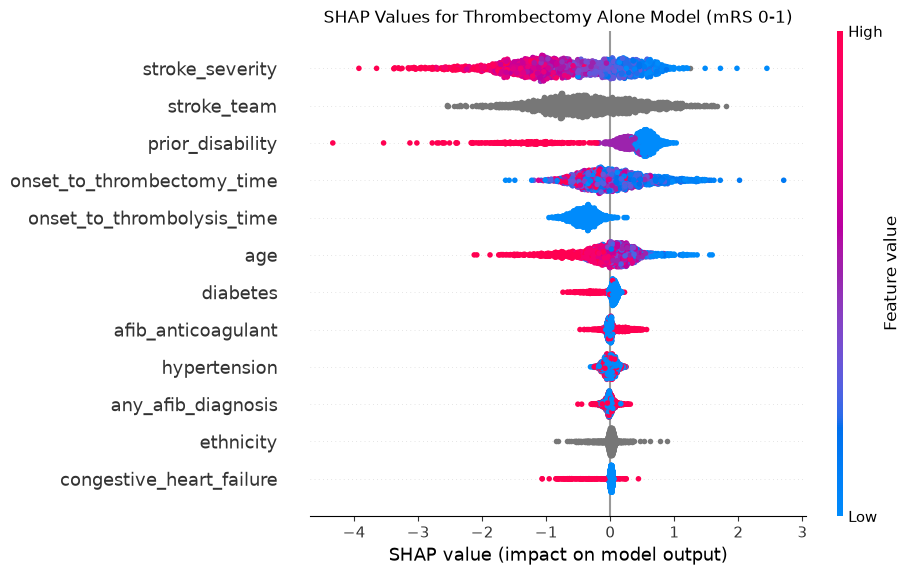

In [22]:
# Get data for patients who received only thrombectomy
only_thrombectomy = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombectomy_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombolysis_time"] == 99999)
].copy()

# Fit regression model for predicted benefit vs thrombectomy time
reg_X = only_thrombectomy[["onset_to_thrombectomy_time"]]
reg_y = only_thrombectomy["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombectomy_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombectomy_time", "onset_to_thrombectomy_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombectomy_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombectomy_time",
    y="log_odds_diff_treated_no_treatment",
    data=only_thrombectomy,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(
    f"Effect of Thrombectomy Time on Predicted Benefit (mRS 0-{mrs_target})\n"
    "(Thrombectomy alone, no thrombolysis)"
)
plt.xlabel('Onset to Thrombectomy Time (mins)')
plt.ylabel(f'Predicted Benefit\n(Log Odds ratio in achieving mRS 0-{mrs_target} vs no treatment)')
plt.savefig(
    f'./output/thrombectomy_alone_time_effect_mrs_{mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()

# Use models[0] to get SHAP values patients receiving only thrombectomy
only_thrombectomy_X = only_thrombectomy[X_fields]
explainer = shap.Explainer(models[0])
shap_values = explainer(only_thrombectomy_X)
# Plot beeswarm plot for SHAP values
shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.title(f"SHAP Values for Thrombectomy Alone Model (mRS 0-{mrs_target})")
plt.savefig(f'./output/shap_beeswarm_thrombectomy_alone_mrs_{mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis of thrombolysis alone

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.050
Model:                                            OLS   Adj. R-squared:                  0.050
Method:                                 Least Squares   F-statistic:                     1271.
Date:                                Sun, 09 Aug 2026   Prob (F-statistic):          3.03e-271
Time:                                        12:28:07   Log-Likelihood:                -26808.
No. Observations:                               24047   AIC:                         5.362e+04
Df Residuals:                                   24045   BIC:                         5.364e+04
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

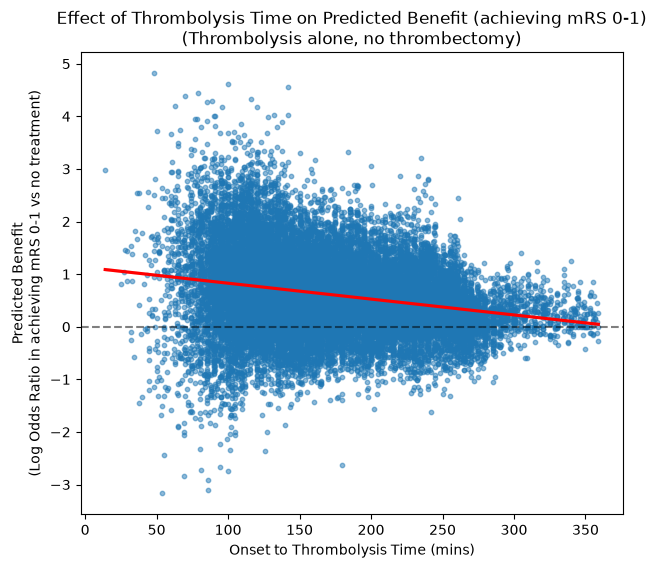

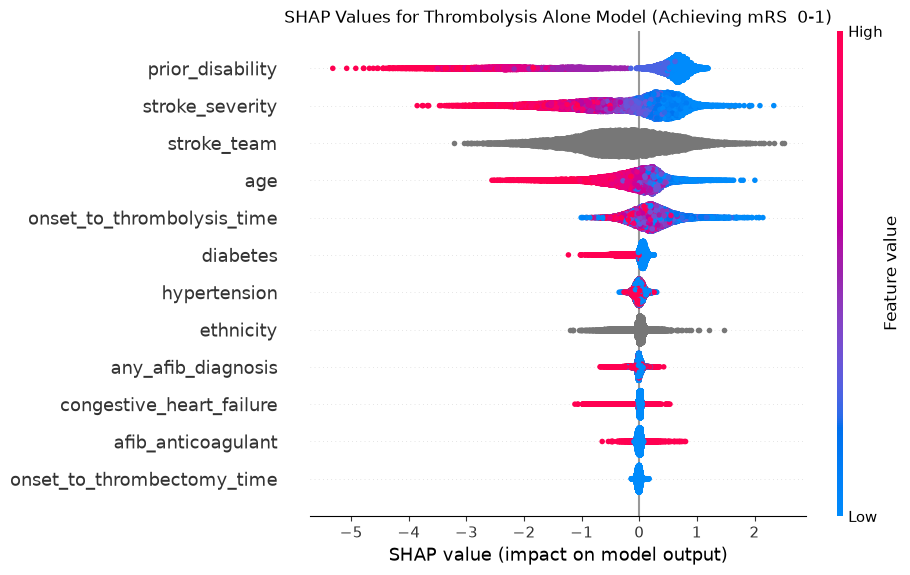

In [23]:
# Get data for patients who received only thrombolysis
only_thrombolysis = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombolysis_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombectomy_time"] == 99999)
].copy()

# Fit regression model for predicted benefit vs thrombolysis time
reg_X = only_thrombolysis[["onset_to_thrombolysis_time"]]
reg_y = only_thrombolysis["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombolysis_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombolysis_time", "onset_to_thrombolysis_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombolysis_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombolysis_time",
    y="log_odds_diff_treated_no_treatment",
    data=only_thrombolysis,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)

# Add a line at y=0
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.title(
    f"Effect of Thrombolysis Time on Predicted Benefit (achieving mRS 0-{mrs_target})\n"
    "(Thrombolysis alone, no thrombectomy)"
)
plt.xlabel("Onset to Thrombolysis Time (mins)")
plt.ylabel(
    f"Predicted Benefit\n(Log Odds Ratio in achieving mRS 0-{mrs_target} vs no treatment)"
)
plt.savefig(
    f"./output/thrombolysis_alone_time_effect_mrs_{mrs_target}.png", dpi=300, bbox_inches="tight")

plt.show()

# Use models[0] to get SHAP values for patients receiving only thrombolysis
only_thrombolysis_X = only_thrombolysis[X_fields]
explainer = shap.Explainer(models[0])
shap_values = explainer(only_thrombolysis_X)

# Plot beeswarm plot for SHAP values
shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.title(f"SHAP Values for Thrombolysis Alone Model (Achieving mRS  0-{mrs_target})")
plt.savefig(
    f"./output/shap_beeswarm_thrombolysis_alone_mrs_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Analysis of thrombectomy and thrombolysis (analyse time to thrombectomy)

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.012
Model:                                            OLS   Adj. R-squared:                  0.011
Method:                                 Least Squares   F-statistic:                     33.92
Date:                                Sun, 09 Aug 2026   Prob (F-statistic):           6.38e-09
Time:                                        12:28:11   Log-Likelihood:                -4656.5
No. Observations:                                2876   AIC:                             9317.
Df Residuals:                                    2874   BIC:                             9329.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

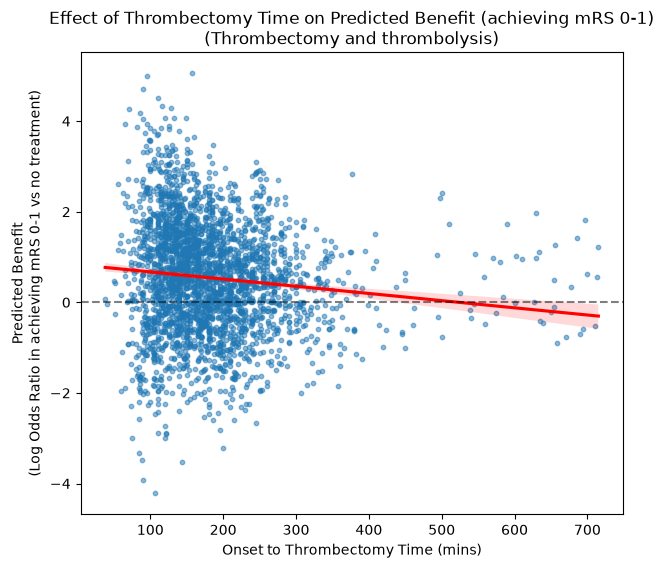

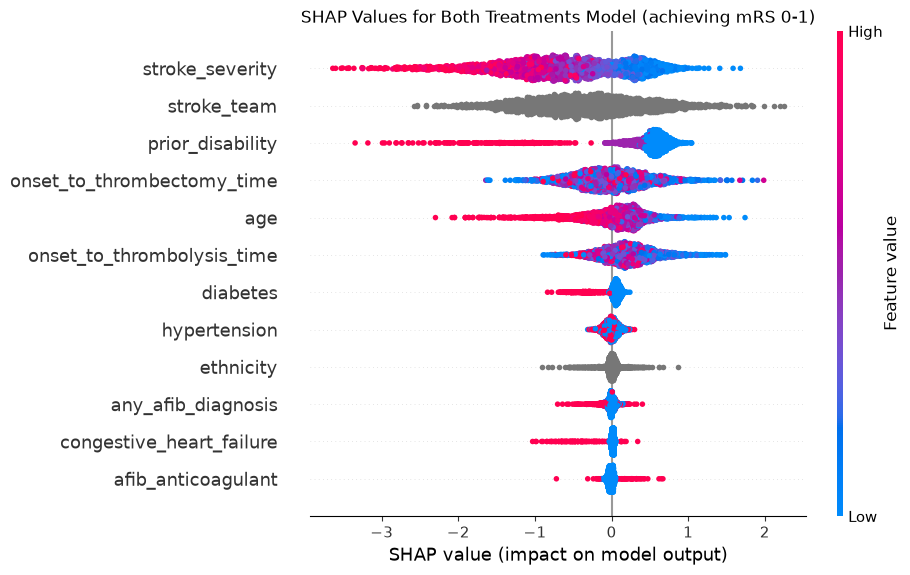

In [24]:
# Get data for patients who thrombectomy and thrombolysis
both_treatments = counter_factuals_df[
    (counter_factuals_df["onset_to_thrombectomy_time"] < 99999)
    & (counter_factuals_df["onset_to_thrombolysis_time"] < 99999)
].copy()

# Fit regression model for predicted benefit vs thrombectomy time
reg_X = both_treatments[["onset_to_thrombectomy_time"]]
reg_y = both_treatments["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombectomy_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombectomy_time", "onset_to_thrombectomy_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombectomy_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombectomy_time",
    y="log_odds_diff_treated_no_treatment",
    data=both_treatments,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(
    f"Effect of Thrombectomy Time on Predicted Benefit (achieving mRS 0-{mrs_target})\n"
    "(Thrombectomy and thrombolysis)"
)
plt.xlabel('Onset to Thrombectomy Time (mins)')
plt.ylabel(f'Predicted Benefit\n(Log Odds Ratio in achieving mRS 0-{mrs_target} vs no treatment)')
plt.savefig(f'./output/thrombectomy_and_thrombolysis_thrombectomy_time_effect_mrs_{
    mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()

# Use patients who received both thrombolysis and thrombectomy
both_treatments_X = both_treatments[X_fields]
explainer = shap.Explainer(models[0])
shap_values = explainer(both_treatments_X)

# Plot beeswarm plot for SHAP values
shap.plots.beeswarm(shap_values, max_display=99, show=False)
plt.title(f"SHAP Values for Both Treatments Model (achieving mRS 0-{mrs_target})")
plt.savefig(
    f"./output/shap_beeswarm_both_treatments_mrs_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Analysis of thrombectomy and thrombolysis (analyse time to thrombolysis)

                                    OLS Regression Results                                    
Dep. Variable:     log_odds_diff_treated_no_treatment   R-squared:                       0.018
Model:                                            OLS   Adj. R-squared:                  0.018
Method:                                 Least Squares   F-statistic:                     53.72
Date:                                Sun, 09 Aug 2026   Prob (F-statistic):           2.99e-13
Time:                                        12:28:12   Log-Likelihood:                -4646.7
No. Observations:                                2876   AIC:                             9297.
Df Residuals:                                    2874   BIC:                             9309.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

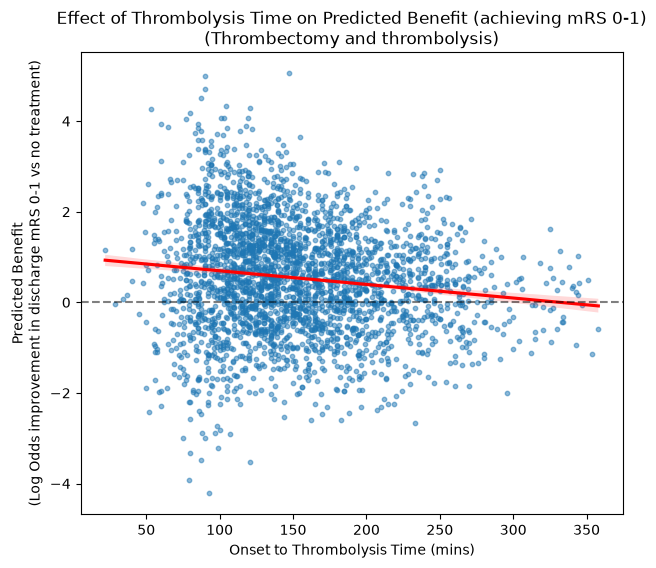

In [25]:
# Fit regression model for predicted benefit vs thrombolysis time
reg_X = both_treatments[["onset_to_thrombolysis_time"]]
reg_y = both_treatments["log_odds_diff_treated_no_treatment"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombolysis_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombolysis_time", "onset_to_thrombolysis_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombolysis_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.regplot(
    x="onset_to_thrombolysis_time",
    y="log_odds_diff_treated_no_treatment",
    data=both_treatments,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title(
    f"Effect of Thrombolysis Time on Predicted Benefit (achieving mRS 0-{mrs_target})\n"
    "(Thrombectomy and thrombolysis)"
)
plt.xlabel('Onset to Thrombolysis Time (mins)')
plt.ylabel(f'Predicted Benefit\n(Log Odds improvement in discharge mRS 0-{mrs_target} vs no treatment)')
plt.savefig(f'./output/thrombectomy_and_thrombolysis_thrombolysis_time_effect_mrs_{
    mrs_target}.png', dpi=300, bbox_inches='tight')
plt.show()


SHAP plot is the same as above.

## Grouped timings

In [26]:
non_categorical_features = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'treatment_group',
]

categorical_features = [
    'stroke_team',
    'ethnicity',
]

X_fields = non_categorical_features + categorical_features

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data[X_fields]
y = (data['discharge_disability'] <= mrs_target).astype(int)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []

for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]
    
    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

In [28]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]
    # Ensure categorical features are treated as categorical
    for cat_feature in categorical_features:
        train_X[cat_feature] = train_X[cat_feature].astype('category')
        test_X[cat_feature] = test_X[cat_feature].astype('category')
    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 0.38
    )
    # Train model
    # Make local copies to avoid chained-assignment issues
    train_X = train_X.copy()
    test_X = test_X.copy()

    # Ensure all string/object columns (e.g., treatment_group) are categorical
    cat_cols = train_X.select_dtypes(include=["object", "category"]).columns

    for col in cat_cols:
        train_X[col] = train_X[col].astype("category")
        # Align test categories to training categories
        test_X[col] = pd.Categorical(test_X[col], categories=train_X[col].cat.categories)

    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.8091, Balanced Accuracy = 0.6720
Split 2: AUC = 0.8147, Balanced Accuracy = 0.6777
Split 3: AUC = 0.8176, Balanced Accuracy = 0.6707
Split 4: AUC = 0.8101, Balanced Accuracy = 0.6767
Split 5: AUC = 0.8077, Balanced Accuracy = 0.6746


In [29]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred_proba = test_y_pred_probas[split]
    y_pred = test_y_preds[split]
    
    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()
    
    print(f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, Predicted positive rate = {predicted_pos_rate:.4f}")

Split 1: Actual positive rate = 0.1692, Predicted positive rate = 0.1784
Split 2: Actual positive rate = 0.1692, Predicted positive rate = 0.1780
Split 3: Actual positive rate = 0.1692, Predicted positive rate = 0.1753
Split 4: Actual positive rate = 0.1693, Predicted positive rate = 0.1774
Split 5: Actual positive rate = 0.1693, Predicted positive rate = 0.1805


In [30]:
counter_factuals = []

for split in range(5):
    model = models[split]
    test_X = test_X_sets[split]
    test_X["treatment_group"]= test_X["treatment_group"].astype("category")

    # Predict probabilities for the test set
    predicted_proba = model.predict_proba(test_X)[:, 1]

    # Change treatment_group to "neither" for counterfactual prediction
    test_X_cf = test_X.copy(deep=True)
    # Set to 'neither' but keep the same dtype and categories
    test_X_cf["treatment_group"] = pd.Categorical(
        ["neither"] * len(test_X_cf),
        categories=test_X["treatment_group"].cat.categories,
        ordered=test_X["treatment_group"].cat.ordered
    )
    # Predict probabilities for the counterfactual set
    predicted_proba_cf = model.predict_proba(test_X_cf)[:, 1]

    # Store X, predicted probabilities, and counterfactual probabilities in a DataFrame
    cf_df = test_X.copy()
    cf_df["predicted_proba"] = predicted_proba
    cf_df["predicted_proba_cf"] = predicted_proba_cf
    cf_df["predicted_proba_shift"] = cf_df["predicted_proba"] - cf_df["predicted_proba_cf"]
    counter_factuals.append(cf_df)

# Concatenate all counterfactual DataFrames into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

In [31]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
counter_factual_summary = counter_factuals_df.groupby("treatment_group")["predicted_proba_shift"].agg(["mean", "std", "count"])
counter_factual_summary["95% CI lower"] = counter_factual_summary["mean"] - 1.96 * counter_factual_summary["std"] / np.sqrt(counter_factual_summary["count"])
counter_factual_summary["95% CI upper"] = counter_factual_summary["mean"] + 1.96 * counter_factual_summary["std"] / np.sqrt(counter_factual_summary["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both"
]
counter_factual_summary = counter_factual_summary.reindex(ordered_arms).round(4)
counter_factual_summary

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.1042,0.1088,23074,0.1028,0.1057
late_thrombolysis_only,0.0092,0.1418,973,0.0003,0.0181
early_thrombectomy_only,0.0484,0.1472,1207,0.0401,0.0567
late_thrombectomy_only,-0.0455,0.1547,526,-0.0587,-0.0323
early_both,0.1208,0.1561,2570,0.1147,0.1268
early_thrombolysis_late_thrombectomy,-0.0287,0.1482,226,-0.0480,-0.0094
late_both,0.0601,0.1962,80,0.0171,0.1031


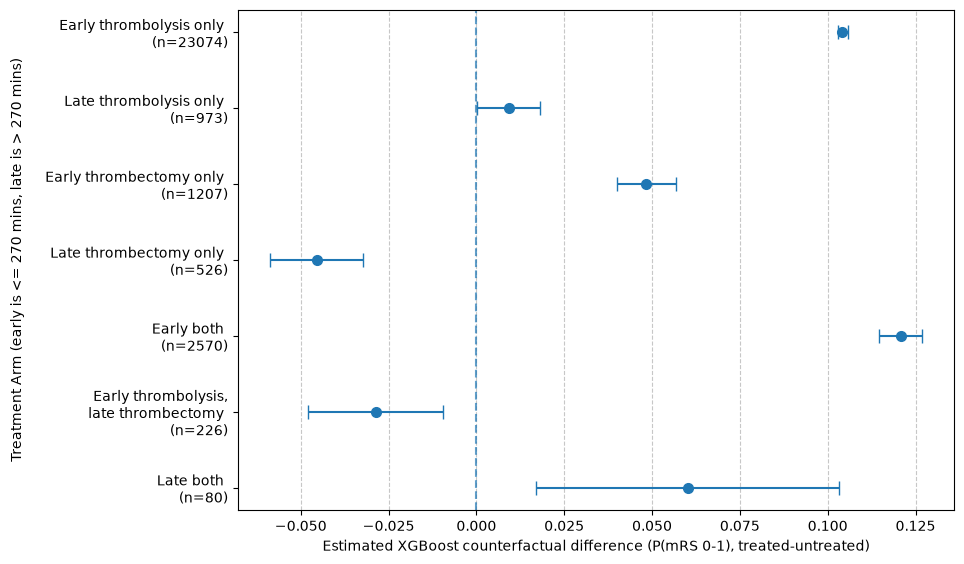

In [32]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
# Add n values to the y tick labels
n_values = counter_factual_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean prob shift with error bars for 95% CI
ax.errorbar(
    y=range(len(counter_factual_summary.index) - 1, -1, -1),
    x=counter_factual_summary["mean"],
    xerr=[
        counter_factual_summary["mean"] - counter_factual_summary["95% CI lower"],
        counter_factual_summary["95% CI upper"] - counter_factual_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Make x min =0
#ax.set_xlim(left=0)
# Set x tick interval of 0.02
#ax.set_xticks(np.arange(0, 0.181, 0.02))
# Add y tick labels for treatment arms
ax.set_yticks(range(len(counter_factual_summary.index) - 1, -1, -1))
# For y tick labels repolace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in counter_factual_summary.index])
# Label the axes
ax.set_xlabel(f"Estimated XGBoost counterfactual difference (P(mRS 0-{mrs_target}), treated-untreated)")

ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/xgboost_counterfactual_cate_estimates_{mrs_target}.png", dpi=300)
plt.show()

Log odds

In [33]:
# Convert predicted_proba and predicted_proba_cf to odds
counter_factuals_df["predicted_odds_control"] = counter_factuals_df["predicted_proba"] / (1 - counter_factuals_df["predicted_proba"])
counter_factuals_df["predicted_odds_treatment"] = counter_factuals_df["predicted_proba_cf"] / (1 - counter_factuals_df["predicted_proba_cf"])
# Log odds
counter_factuals_df["predicted_log_odds_control"] = np.log(counter_factuals_df["predicted_odds_control"])
counter_factuals_df["predicted_log_odds_treatment"] = np.log(counter_factuals_df["predicted_odds_treatment"])
counter_factuals_df["log_odds_shift"] = counter_factuals_df["predicted_log_odds_control"] - counter_factuals_df["predicted_log_odds_treatment"]

In [34]:
# Calculate mean, SD, and 95% CI of CATE for each treatment arm
counter_factual_summary_log_odds = counter_factuals_df.groupby("treatment_group")["log_odds_shift"].agg(["mean", "std", "count"])
counter_factual_summary_log_odds["95% CI lower"] = counter_factual_summary_log_odds["mean"] - 1.96 * counter_factual_summary_log_odds["std"] / np.sqrt(counter_factual_summary_log_odds["count"])
counter_factual_summary_log_odds["95% CI upper"] = counter_factual_summary_log_odds["mean"] + 1.96 * counter_factual_summary_log_odds["std"] / np.sqrt(counter_factual_summary_log_odds["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both"
]
counter_factual_summary_log_odds = counter_factual_summary_log_odds.reindex(ordered_arms).round(4)
counter_factual_summary_log_odds

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.8063,0.6593,23074,0.7978,0.8148
late_thrombolysis_only,-0.1308,1.0001,973,-0.1936,-0.0679
early_thrombectomy_only,0.4741,1.0847,1207,0.4129,0.5353
late_thrombectomy_only,-0.6428,1.2456,526,-0.7492,-0.5363
early_both,0.9900,0.9863,2570,0.9519,1.0281
early_thrombolysis_late_thrombectomy,-0.3735,1.1634,226,-0.5251,-0.2218
late_both,0.3575,1.2434,80,0.0851,0.6300


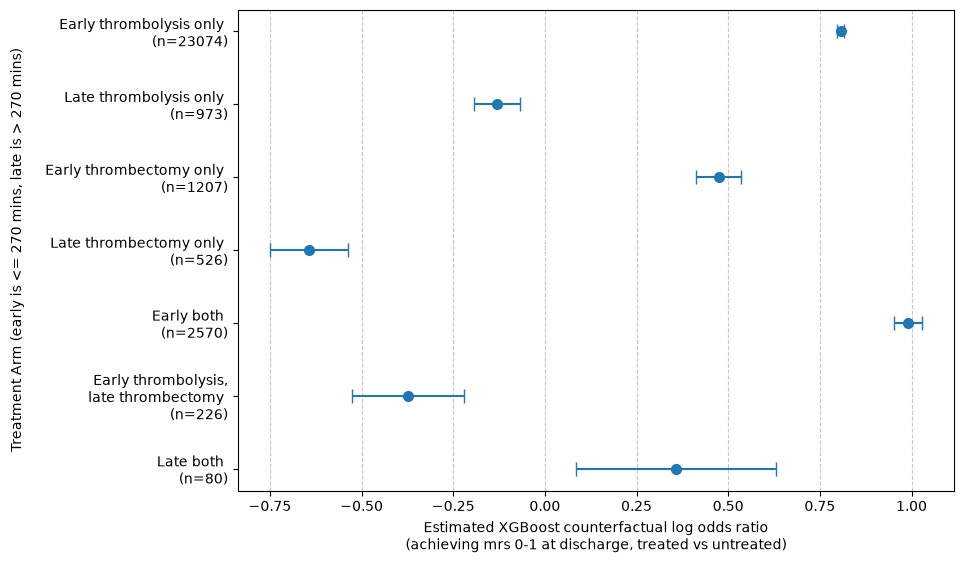

In [36]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
# Add n values to the y tick labels
n_values = counter_factual_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean prob shift with error bars for 95% CI
ax.errorbar(
    y=range(len(counter_factual_summary_log_odds.index) - 1, -1, -1),
    x=counter_factual_summary_log_odds["mean"],
    xerr=[
        counter_factual_summary_log_odds["mean"] - counter_factual_summary_log_odds["95% CI lower"],
        counter_factual_summary_log_odds["95% CI upper"] - counter_factual_summary_log_odds["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)

# Add y tick labels for treatment arms
ax.set_yticks(range(len(counter_factual_summary.index) - 1, -1, -1))
# For y tick labels repolace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in counter_factual_summary_log_odds.index])
# Label the axes
ax.set_xlabel(f"Estimated XGBoost counterfactual log odds ratio\n(achieving mrs 0-{mrs_target} at discharge, treated vs untreated)")
ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/xgboost_counterfactual_cate_log_odds_estimates_{mrs_target}.png", dpi=300)
plt.show()